# Advection 1D périodique

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr
import IPython.display as ipd


import matplotlib.colors as colors

#Modules maison
import Fourier
import Chebyshev
import Params
import TimeScheme

In [3]:
import sympy as sp
sp.init_printing(use_latex=True)

In [4]:
def loop(U0, RHS, Tmax = 2.0, dt = 0.01, scheme = 'Euler', diag = None):
    "Uniquement pour pas de temps fixes"
    N_it_max = int(np.round(Tmax/dt))
    u = np.zeros((N_it_max, U0.size))
    liste_t = np.zeros(N_it_max)
    liste_diag = np.zeros(N_it_max)
    t_ = 0.0
    u[0] = U0
    
    params = Params.Params()
    params.time_scheme = scheme
    TS = TimeScheme.TimeScheme(params, RHS, U0)
    for i in range(1, N_it_max):
        u[i, :] = TS.Step(dt)
        t_ += dt
        liste_t[i] = t_
    if diag !=None:
        for i in range(0, N_it_max) : 
            liste_diag[i] = diag(u[i, :])
        return u, liste_t, liste_diag
    return u, liste_t

In [5]:
def animate(Da, width=500, height=500,clim=None, title=None, cmap = 'seismic') :
    cmap='seismic'
    if clim == None : 
        clim = (float(Da.min()), float(Da.max()))
    
    anim = Da.hvplot(groupby='t',
                     title=title,
                     framewise=False,
                     width=width,
                     height=height,
                     widget_type="scrubber",
                     widget_location="bottom",
                     clim=clim,
                     cmap=cmap)
    return anim

## Equation d'advection 1D avec CLs périodiques
On résout l'équation 
$$
\begin{aligned}
\frac{\partial u(x, t)}{\partial t} &= c_0\frac{\partial u(x, t)}{\partial x}\\
u(x, 0) &= e^{-\frac{x^2}{2\sigma^2}}\\
x&\in[0, 2\pi]\\
u(0, t) &= u(2\pi, t)
\end{aligned}
$$

Nx = 128
dx = 0.0078125
c=100.0
dt = 7.8125e-07
CFL = 0.01
u_sum(0) = 0.24870440874886982


C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


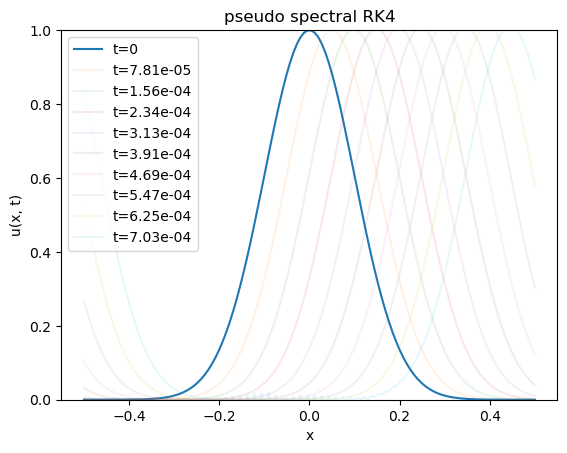

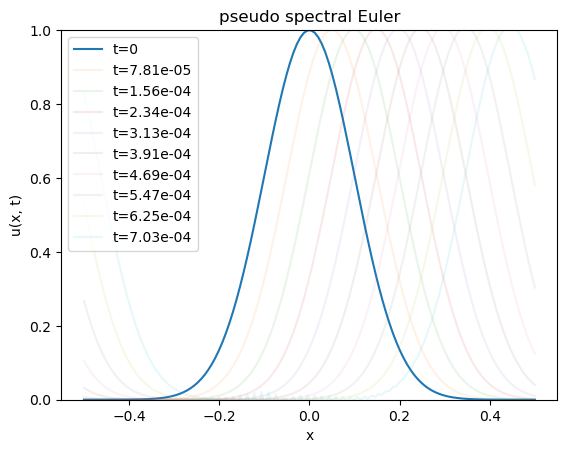

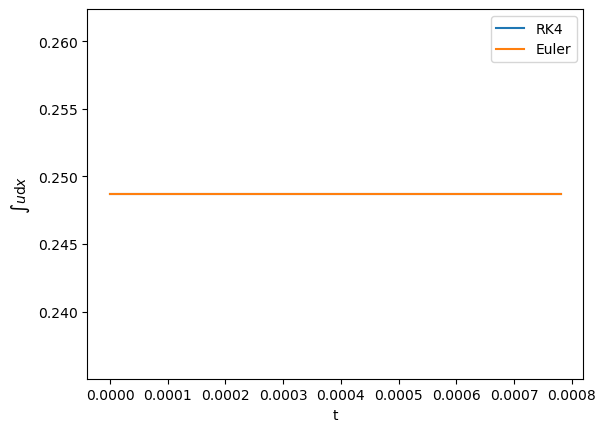

In [5]:
L = 1.0

Nx = 128

print(f"Nx = {Nx}")

x = np.linspace(-L/2., L/2., Nx, endpoint = True)

sigma = 0.1
u0 = np.exp( -x**2/(2.*sigma**2) )
u = u0.copy()

dx = L/Nx

CFL = 0.01

print(f"dx = {dx}")

c=100.0
print(f"c={c}")


dt = CFL*dx/c
#dt =1.0e-6


print(f"dt = {dt}")
print(f"CFL = {CFL}")
Nt = 1000

u_res = [u]

t=0.0
t_tot = [t]

time_scheme ='Euler'

u_int = [Fourier.Fourier_quad(u0, dx)]

def RK4(x, rhs, delta_t, *args, **kwargs):
    k1 = rhs(x, *args, **kwargs)
    k2 = rhs(x+0.5*delta_t*k1, *args, **kwargs)
    k3 = rhs(x+0.5*delta_t*k2, *args, **kwargs)
    k4 = rhs(x+delta_t*k3, *args, **kwargs)

    return x+delta_t*(k1+2.0*k2+2.0*k3+k4)/6.0

def u_tot(U):
    return np.sum(U)
def rhs_adv(x):
    return -c*Fourier.Fourier_deriv(u, a=-L/2., b=L/2., real =False)

u_int =[Fourier.Fourier_quad(u0, dx)]
print(f"u_sum(0) = {Fourier.Fourier_quad(u0, dx)}")

u_euler = u0.copy()
u_euler_t = [u_euler]
u_int_euler = [Fourier.Fourier_quad(u0, dx)]

for i in range(0, Nt):
    u_euler = u_euler - c*dt*Fourier.Fourier_deriv(u_euler, a=-L/2., b=L/2.)#intégration par méthode d'Euler
    u = RK4(u, rhs_adv, dt)
    u_res.append(u)
    u_int.append(Fourier.Fourier_quad(u.real, dx))
    u_int_euler.append(Fourier.Fourier_quad(u_euler, dx))
    u_euler_t.append(u_euler)
    t+=dt
    t_tot.append(t)


Da_1D = xr.DataArray(np.array(u_res).real, dims=['t', 'x'], coords = {'x' : x, 't':t_tot})

step_plot =100

fig = plt.figure()
plt.title("pseudo spectral RK4")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_res[i], label=f't={i*dt:.2e}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)

fig = plt.figure()
plt.title("pseudo spectral Euler")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_euler_t[i], label=f't={i*dt:.2e}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()
plt.plot(t_tot, u_int, label = 'RK4')
plt.plot(t_tot, u_int_euler, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()
#plt.ylim(31., 33.)

## Advection 1D avec CLs de Dirichlet
On veut résoudre l'équation suivante, sur $x\in[-\frac{\pi}{2},\frac{\pi}{2}$ : 
$$
\begin{aligned}
\frac{\partial u(x, t)}{\partial t} &= \cos(x)\frac{\partial u(x, t)}{\partial x}\\
u(-\frac{\pi}{2}, t) &= u(\frac{\pi}{2}, t)=0\\
u(x, 0) &=  \cos(x)
\end{aligned}
$$

CFL = 0.1
dx_min =0.0009462364709564153
c_max = 0.9992333045023272
dt = 9.469625028438107e-05
Nt_Euler = 2.112e+04


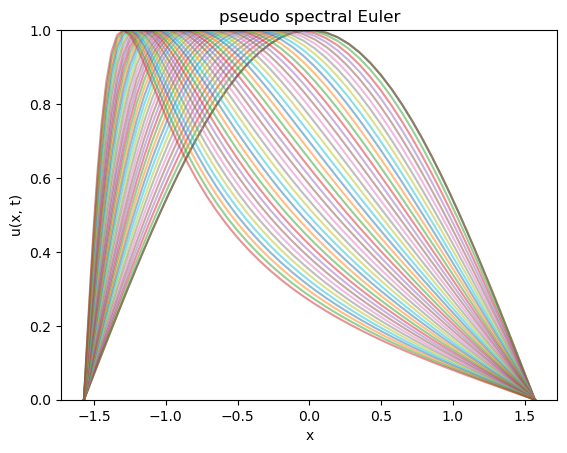

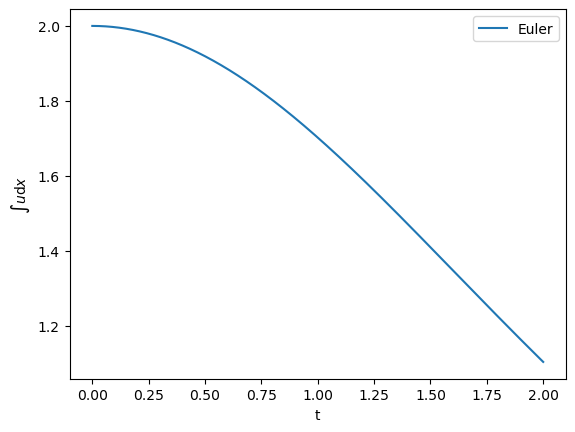

In [6]:
Nx_ = 64
X = Chebyshev.collocation_points(Nx_, a = -np.pi/2.0, b= np.pi/2.0)

u0_ = np.cos(X)

dx = (np.pi/2.0) * (np.pi/(2.0*Nx_))**2
#    (b-a)/2     * dx_min

comp_tot = lambda xx : Chebyshev.Cheb_quad(xx, a=-np.pi/2.0, b = np.pi/2.0)
c = lambda xx : np.cos(xx)
c_x = c(X)

u_ana = lambda xx, tt : np.cos(xx)*np.exp(-np.sin(xx)*tt)

rhs_adv_Cheb = lambda uu, t:c_x*Chebyshev.Cheb_FFT(uu, a = -np.pi/2.0, b=np.pi/2.0)


CFL = 0.1
c_max = np.max(c_x)
dt = CFL*dx/c_max
Tmax = 2.0


print(f"CFL = {CFL}")
print(f"dx_min ={dx}")
print(f"c_max = {c_max}")
print(f"dt = {dt}")

u_Euler, t_Euler, u_tot_Euler = loop(u0_, rhs_adv_Cheb, Tmax = Tmax, dt = dt, scheme = 'Euler', diag = comp_tot)

Nt_Euler = u_Euler.shape[0]
print(f"Nt_Euler = {Nt_Euler:.3e}")

fig = plt.figure()
plt.title("pseudo spectral Euler")
plt.plot(X, u0_, label='t=0')
step_plot = 500
for i in range(0, Nt_Euler):
    if i %step_plot ==0 : 
        plt.plot(X,u_Euler[i, :], label=f't={i*dt:.2e}', alpha =0.5)
plt.xlabel("x")
plt.ylabel("u(x, t)")
#plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()

plt.plot(t_Euler, u_tot_Euler, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()



In [9]:
Da_Euler = xr.DataArray(np.array(u_Euler), dims=['t', 'x'], coords = {'x' : X, 't':t_Euler})

animate(Da_Euler)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=21119, width=550)

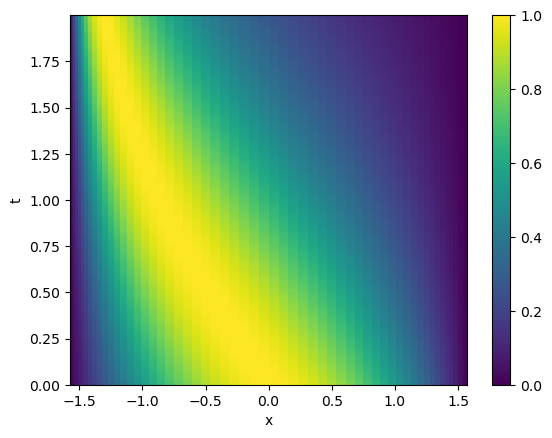

In [10]:
XX, TT = np.meshgrid(X, t_Euler, indexing = 'ij')

fig = plt.figure()
Da_Euler.plot()


Nt_RK2= 2.112e+04
CFL = 0.1
dx_min =0.0009462364709564153
c_max = 0.9992333045023272
dt = 9.469625028438107e-05


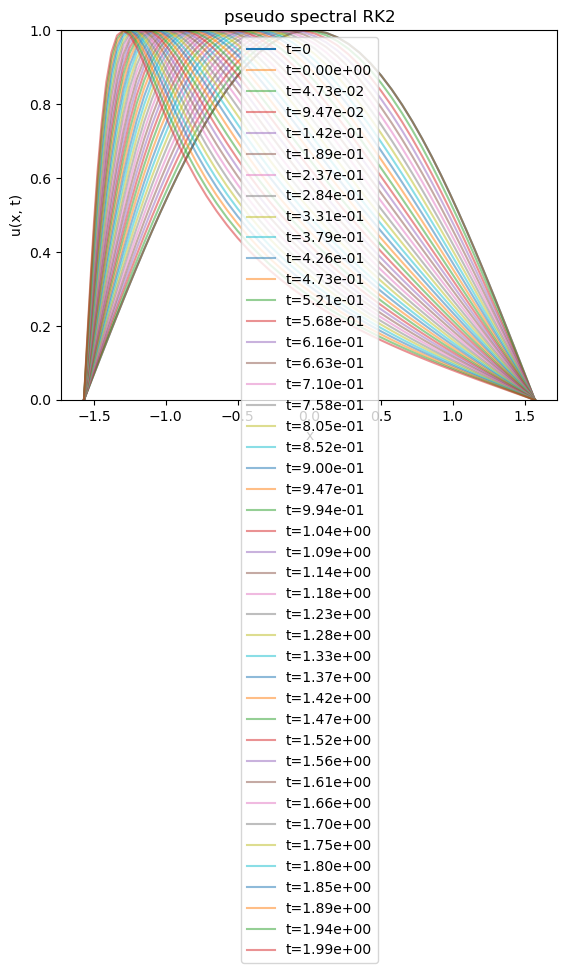

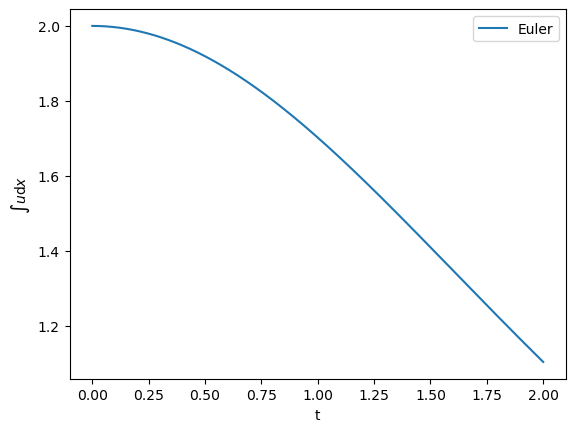

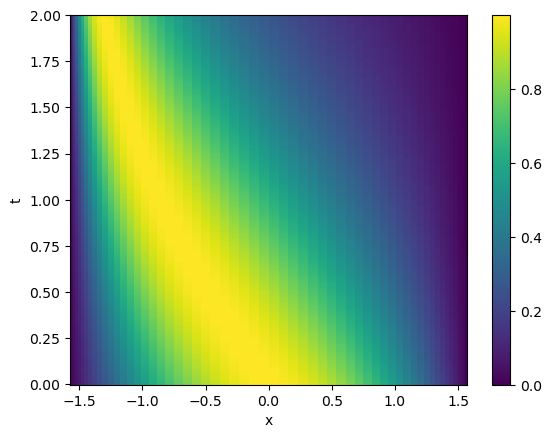

In [11]:
CFL = 0.1
c_max = np.max(c_x)
dt = CFL*dx/c_max
Tmax = 2.0


u_RK2, t_RK2, u_tot_RK2 = loop(u0_, rhs_adv_Cheb, Tmax = Tmax, dt = dt, scheme = 'RK2', diag = comp_tot)

Nt_RK2 = u_RK2.shape[0]
print(f"Nt_RK2= {Nt_RK2:.3e}")

print(f"CFL = {CFL}")
print(f"dx_min ={dx}")
print(f"c_max = {c_max}")
print(f"dt = {dt}")


fig = plt.figure()
plt.title("pseudo spectral RK2")
plt.plot(X, u0_, label='t=0')
step_plot = 500
for i in range(0, Nt_RK2):
    if i %step_plot ==0 : 
        plt.plot(X,u_RK2[i, :], label=f't={i*dt:.2e}', alpha =0.5)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()

plt.plot(t_RK2, u_tot_RK2, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()



Da_RK2 = xr.DataArray(np.array(u_RK2)[::50,:], dims=['t', 'x'], coords = {'x' : X, 't':t_RK2[::50]})
fig = plt.figure()
Da_RK2.plot()

## Burgers avec CLs périodiques et schéma RK2, avec pas de temps adaptatif

On résout l'équation 
$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}
$$

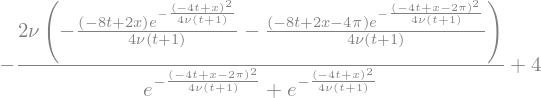

In [11]:
x, nu, t, u_ana = sp.symbols('x nu t u_{ana}')
phi = (sp.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sp.exp(-(x - 4 * t - 2 * sp.pi)**2 / (4 * nu * (t + 1))))

u_ana = -2*nu*phi.diff(x)/phi+4
ipd.display(u_ana)
func_u_ana = sp.utilities.lambdify((x, t, nu), u_ana)

dx = 0.04908738521234052
CFL = 0.01
visc = 0.1
Schéma temporel RK2
debut boucle
####################################################
####################################################
nombre d'itérations 50547


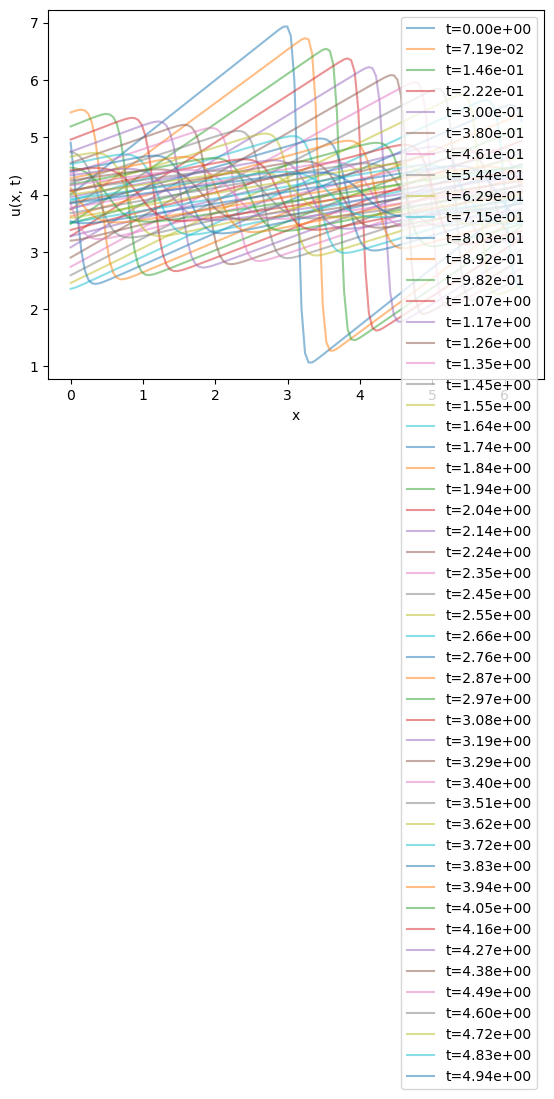

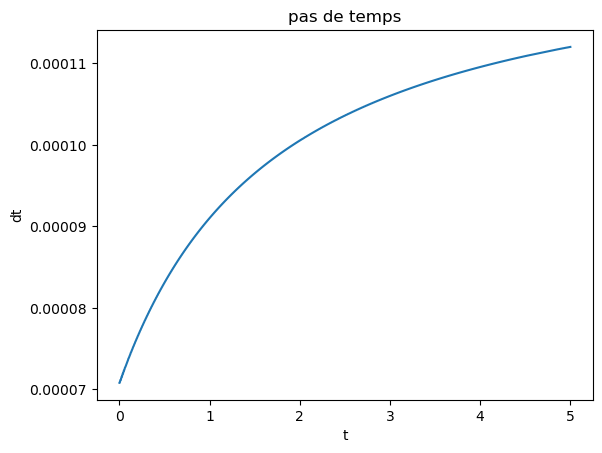

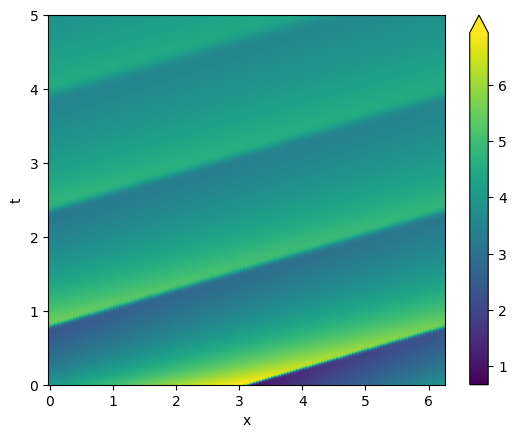

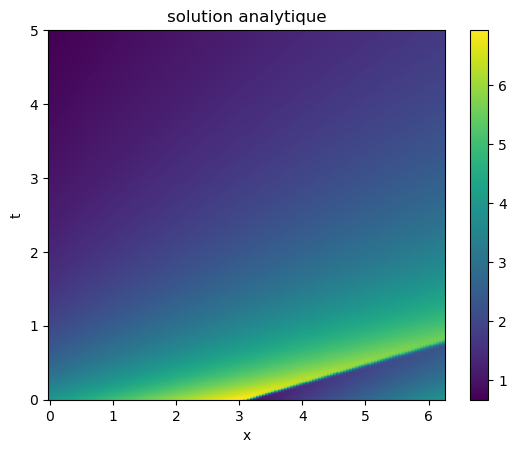

In [12]:
visc=0.1

Nx = 128
x = np.linspace(0.0, 2.0*np.pi,Nx, endpoint = False)
dx = x[1]-x[0]


rhs_Bu_Fourier = lambda uu, tt : -uu*Fourier.Fourier_deriv(uu, order=1) + visc*Fourier.Fourier_deriv(uu, order=2)
u_F = func_u_ana(x, 0, visc)


Tmax = 5.0
CFL = 0.01
N_it_max = 100000
N_it = 0
u_max = 10.0


print(f"dx = {dx}")
print(f"CFL = {CFL}")
print(f"visc = {visc}")


liste_t = [0.0]
liste_u = [u_F]

t = 0.0

dt = CFL * dx/np.max(u_F)
liste_dt = [dt]

params = Params.Params()
params.time_scheme = 'RK2'
TS = TimeScheme.TimeScheme(params, rhs_Bu_Fourier, u_F.copy())

print(f"Schéma temporel {params.time_scheme}")

print("debut boucle")
print(f"####################################################")
while (t <= Tmax) : 
    N_it += 1
    #dt = 0.0001
    t+=dt
    u_i= TS.Step(dt)
    #print(f"t={t}")
    dt = CFL * dx/np.max(u_i)
    #print(f"U max = {np.max(u_i):.3f}")
    #print(f"dt={dt:.3f}")
    
    if np.max(u_i) >= u_max:
        print(f"Dépassement de valeur limite (u_max = {u_max}) en t) {t}")
        break
    liste_dt.append(dt)
    liste_u.append(u_i)
    liste_t.append(t)
    if N_it >= N_it_max : 
        print("nombre maximum d'itérations atteint")
        break
    
print("####################################################")
liste_u = np.array(liste_u)
Da_Bu_F = xr.DataArray(liste_u, dims=['t', 'x'], coords = {'x' : x, 't':liste_t})
print(f"nombre d'itérations {N_it}")


fig = plt.figure()
step_plot = 1000
for i in range(0, N_it):
    if i %step_plot ==0 : 
        plt.plot(x,liste_u[i, :], label=f't={liste_t[i]:.2e}', alpha =0.5)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()

XX, TT = np.meshgrid(x, np.linspace(0.0, Tmax, 1000), indexing = 'ij')
sol_ana = func_u_ana(XX, TT, visc)


fig = plt.figure()
plt.plot(liste_t, liste_dt)
plt.xlabel('t')
plt.ylabel('dt')
plt.title('pas de temps')

fig=plt.figure()
Da_Bu_F.plot(vmin = sol_ana.min(), vmax = sol_ana.max())


fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(XX, TT, sol_ana)
ax.set_xlabel('x')
ax.set_ylabel('t')
fig.colorbar(cf, ax=ax)

In [13]:
animate(Da_Bu_F)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=50547, width=550)

In [14]:
Da_ana = xr.DataArray(sol_ana, dims=['x', 't'], coords = {'x' : x, 't':np.linspace(0.0, Tmax, 1000)})

animate(Da_ana)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=999, width=550)

## Résolution de cette meme équation avec CLs de Dirichlet
$x\in[0, 1]$, $u(0, t) = u(1, t) = 0$

In [15]:
import tqdm.notebook as tqdm

nombre d'itérations 21419


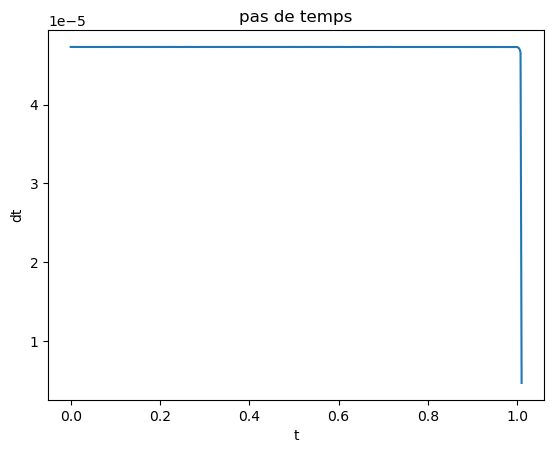

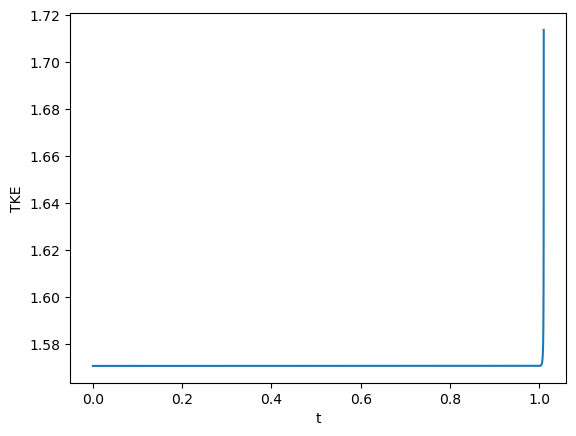

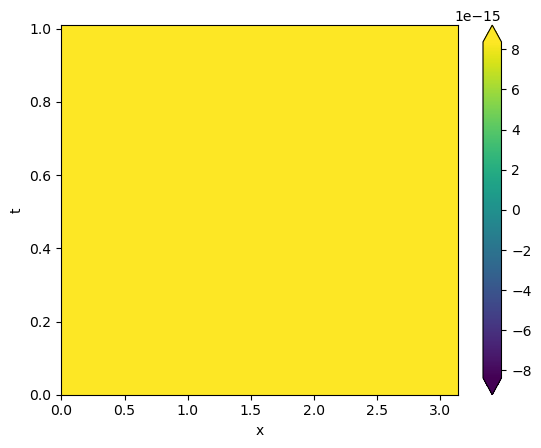

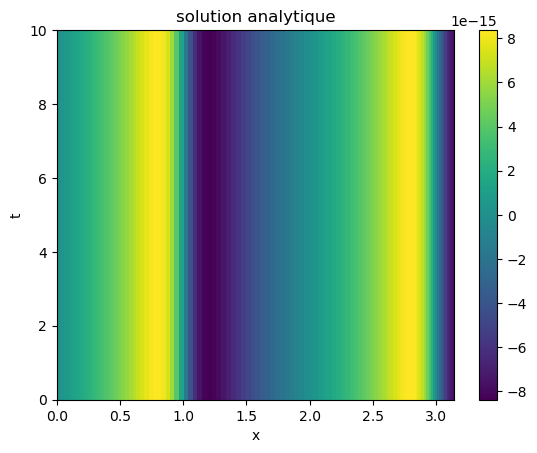

In [6]:
Nx_C = 128
x_inf = 0.0
x_sup = np.pi

visc = 1.0e-15

x_C = Chebyshev.collocation_points(Nx_C, a=x_inf, b= x_sup)
dx_C = (x_sup - x_inf)*0.25*(np.pi/Nx_C)**2
D =Chebyshev.Cheb_mat(Nx_C, a=x_inf, b=x_sup)
D_Dirichlet = D.copy()
D_Dirichlet[0,0] = 1.0; D_Dirichlet[0, 1:-1] = 0.0
D_Dirichlet[-1, -1] = 1.0;D_Dirichlet[-1, 0:-1]=0.0
D2 = D@D

def RHS_Bu_C(UU, tt):
    res = -UU*(D_Dirichlet@UU) + visc*(D2@UU)
    return res


beta= 4.0
alpha = 5.0
u_ana = lambda xx, tt : (2.0*visc*beta*np.pi*np.exp(-visc* (np.pi**2) * tt)*np.sin(np.pi*xx))/(alpha+beta*np.exp(-visc*(np.pi**2)*tt)*np.cos(np.pi*xx))
#u_ini = u_ana(x_C, 0.0)
u_ini = np.sin(x_C)


Tmax = 10.0
CFL_adv = 0.1
CFL_diff = 0.1
N_it_max = 10000000
N_it = 0
u_max = 10.0


print(f"dx = {dx_C}")
print(f"CFL_adv = {CFL_adv}")
print(f"CFL_diff = {CFL_diff}")
print(f"visc = {visc}")


liste_t = [0.0]
liste_u_C = [u_ini]

CS = 10000
t = 0.0

dt = min(CFL_adv * dx_C/np.max(np.abs(u_ini)), CFL_diff*(dx_C**2)/(visc*CS))
liste_dt = [dt]

params = Params.Params()
params.time_scheme = 'RK2'
TS = TimeScheme.TimeScheme(params, RHS_Bu_C, u_ini.copy())

print(f"Schéma temporel {params.time_scheme}")

print("debut boucle")
print(f"####################################################")
#pbar = tqdm.tqdm(total=Tmax)
while (t <= Tmax) : 
    N_it += 1
    #dt = 0.0001
    t+=dt
    u_i= TS.Step(dt)
    #print(f"t={t}")
    #dt = CFL * dx_C/np.max(np.abs(u_i))
    u_max_i = np.max(np.abs(u_i))
    dt = min(CFL_adv * dx_C/u_max_i, CFL_diff*(dx_C**2)/(visc*CS))
    #print(f"U max = {np.max(u_i):.3f}")
    #print(f"dt={dt:.3f}")
    if (N_it%1)==0:
        liste_dt.append(dt)
        liste_u_C.append(u_i)
        liste_t.append(t)
    """
    if N_it %100 == 0:
        pbar.update()
    """
    if np.abs(np.max(u_i)) >= u_max:
        print(f"ERREUR - Dépassement de valeur limite (u_max = {u_max}) en t) {t}. Arret du calcul")
        break
    if N_it >= N_it_max : 
        print("nombre maximum d'itérations atteint")
        break
    print("####################################################")
    print(f"t = {t}")
    print(f"u[0] = {u_i[0]}, u[-1] = {u_i[-1]}")
    print(f"N_it ={N_it}/{N_it_max}")
    print(f"u_max = {u_max_i}")
    print(f"dt = {dt}")
    print("####################################################")
    ipd.clear_output(wait=True)
print("####################################################")
#pbar.close()
liste_u_C = np.array(liste_u_C)
Da_Bu_C = xr.DataArray(liste_u_C, dims=['t', 'x'], coords = {'x' : x_C, 't':liste_t})
print(f"nombre d'itérations {N_it}")

liste_TKE = np.zeros_like(liste_t)
for i in range(0, liste_TKE.size):
    liste_TKE[i] = Chebyshev.Cheb_quad(liste_u_C[i]**2, a=x_inf, b=x_sup)
"""
fig = plt.figure()
step_plot = 100
for i in range(0, N_it):
    if i %step_plot ==0 : 
        plt.plot(x_C,liste_u_C[i, :], label=f't={liste_t[i]:.2e}', alpha =0.5)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
"""
XX, TT = np.meshgrid(x_C, np.linspace(0.0, Tmax, 1000), indexing = 'ij')
sol_ana = u_ana(XX, TT)


fig = plt.figure()
plt.plot(liste_t, liste_dt)
plt.xlabel('t')
plt.ylabel('dt')
plt.title('pas de temps')

fig = plt.figure()
plt.plot(liste_t, liste_TKE)
plt.xlabel('t')
plt.ylabel('TKE')


fig=plt.figure()
Da_Bu_C.plot(vmin = sol_ana.min(), vmax = sol_ana.max())


fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(XX, TT, sol_ana)
ax.set_xlabel('x')
ax.set_ylabel('t')
fig.colorbar(cf, ax=ax)



In [17]:
Chebyshev.ChebDiff_FFT(u_ini, M=1)

array([-1.57079633, -1.57079615, -1.57079343, -1.57078165, -1.57074996,
       -1.57068324, -1.57056209, -1.57036296, -1.57005818, -1.56961606,
       -1.56900101, -1.56817367, -1.56709101, -1.56570652, -1.5639704 ,
       -1.56182971, -1.55922863, -1.55610867, -1.55240891, -1.54806632,
       -1.54301603, -1.53719163, -1.53052555, -1.52294936, -1.51439421,
       -1.50479118, -1.4940717 , -1.48216798, -1.46901347, -1.45454325,
       -1.43869458, -1.42140729, -1.40262428, -1.382292  , -1.3603609 ,
       -1.33678588, -1.31152676, -1.28454873, -1.25582271, -1.22532578,
       -1.19304154, -1.15896043, -1.12308005, -1.0854054 , -1.04594907,
       -1.00473147, -0.96178091, -0.91713364, -0.87083394, -0.82293399,
       -0.77349383, -0.72258119, -0.67027122, -0.61664631, -0.56179566,
       -0.50581498, -0.44880599, -0.39087594, -0.3321371 , -0.27270618,
       -0.21270368, -0.15225328, -0.09148117, -0.03051529,  0.03051529,
        0.09148117,  0.15225328,  0.21270368,  0.27270618,  0.33

In [7]:
animate(Da_Bu_C)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=21419, width=550)

In [19]:
liste_u_C.shape

N1 = 128
max(eig(D2_N1)) = 4995484.907292479
max(eig(D_N1_Dirichlet)) = 910.4348834372678
N2 = 512
max(eig(D2_N2)) = 1308895470.9364765
max(eig(D_N2)) = 14731.80020585107


Text(0, 0.5, 'Im')

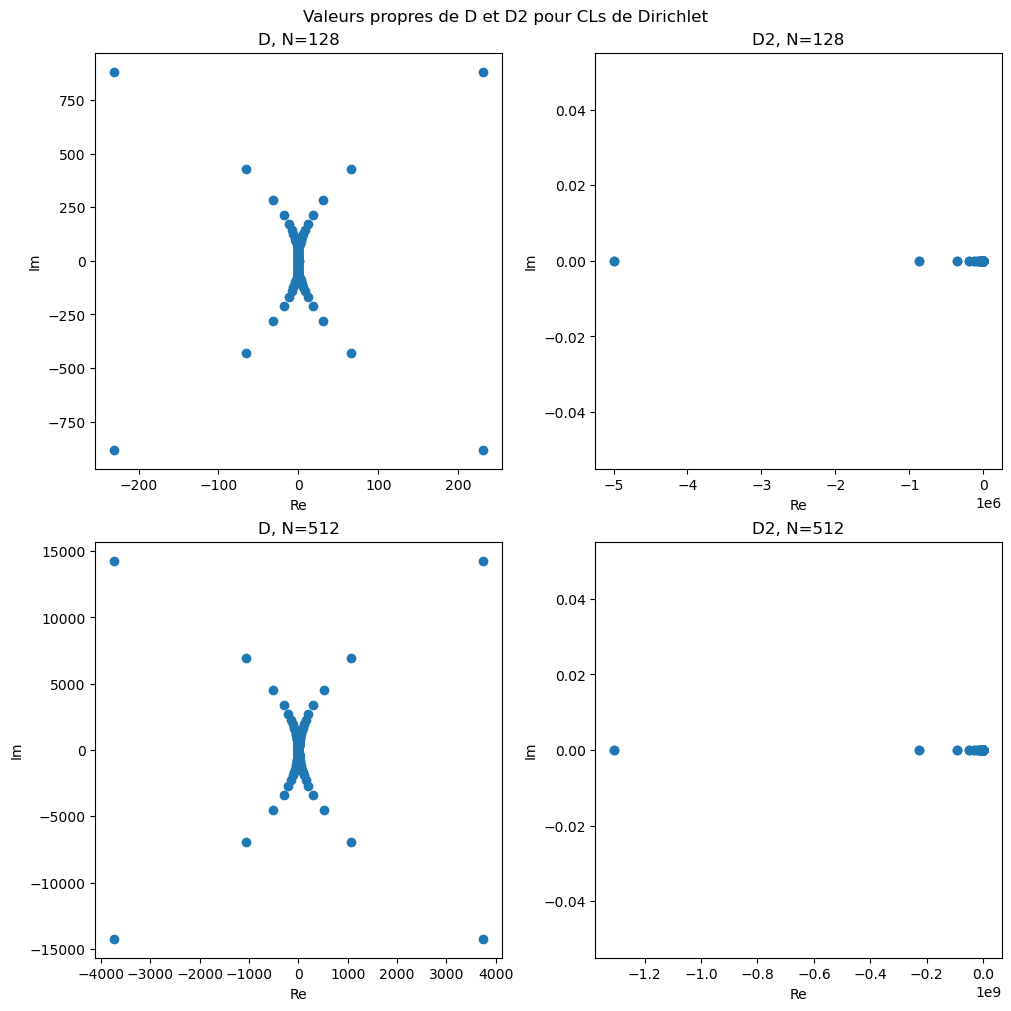

In [8]:
N1=128
N2 = 512
D_N1 = Chebyshev.Cheb_mat(N1, a= 0.0, b=np.pi)
#CL Dirichlet
D_N1_Dirichlet = Chebyshev.Cheb_mat(N1, a = 0.0, b = np.pi, Dirichlet_BC = True)
D2_N1_Dirichlet = Chebyshev.Cheb_mat(N1, a=0.0, b=np.pi, Dirichlet_BC=True, M=2)
D4_N1 =  Chebyshev.Cheb_mat(N1, a=0.0, b=np.pi, M=4)

eigs_D2_N1 = scipy.linalg.eigvals(D2_N1_Dirichlet)
eigs_D_N1 = scipy.linalg.eigvals(D_N1_Dirichlet)

D_N2 = Chebyshev.Cheb_mat(N2, a= 0.0, b=np.pi)

D_N2_Dirichlet = Chebyshev.Cheb_mat(N2, a = 0.0, b = np.pi, Dirichlet_BC = True)
D2_N2_Dirichlet = Chebyshev.Cheb_mat(N2, a=0.0, b=np.pi, Dirichlet_BC=True, M=2)
D4_N2 = Chebyshev.Cheb_mat(N2, a=0.0, b=np.pi, M=4)
eigs_D2_N2 = scipy.linalg.eigvals(D2_N2_Dirichlet)
eigs_D_N2 = scipy.linalg.eigvals(D_N2_Dirichlet)

print(f"N1 = {N1}")
print(f"max(eig(D2_N1)) = {np.max(np.abs(eigs_D2_N1))}") 
print(f"max(eig(D_N1_Dirichlet)) = {np.max(np.abs(eigs_D_N1))}") 

print(f"N2 = {N2}")
print(f"max(eig(D2_N2)) = {np.max(np.abs(eigs_D2_N2))}") 
print(f"max(eig(D_N2)) = {np.max(np.abs(eigs_D_N2))}") 

fig = plt.figure( figsize  = (10, 10), constrained_layout = True)
axs = fig.subplots(2, 2, squeeze = False, sharex = False, sharey = False)
fig.suptitle("Valeurs propres de D et D2 pour CLs de Dirichlet")


axs[0, 0].set_title(f"D, N={N1}")
axs[0, 0].scatter(eigs_D_N1.real, eigs_D_N1.imag)
axs[0, 0].set_xlabel(r"Re")
axs[0, 0].set_ylabel(r"Im")

axs[0, 1].set_title(f"D2, N={N1}")
axs[0, 1].scatter(eigs_D2_N1.real, eigs_D2_N1.imag)
axs[0, 1].set_xlabel(r"Re")
axs[0, 1].set_ylabel(r"Im")


axs[1, 0].set_title(f"D, N={N2}")
axs[1, 0].scatter(eigs_D_N2.real, eigs_D_N2.imag)
axs[1, 0].set_xlabel(r"Re")
axs[1, 0].set_ylabel(r"Im")


axs[1, 1].set_title(f"D2, N={N2}")
axs[1, 1].scatter(eigs_D2_N2.real, eigs_D2_N2.imag)
axs[1, 1].set_xlabel(r"Re")
axs[1, 1].set_ylabel(r"Im")

In [47]:
eigs_D_N1

array([ 2.31001291e+02+880.64185724j,  2.31001291e+02-880.64185724j,
       -2.31001291e+02+880.64185724j, -2.31001291e+02-880.64185724j,
        6.54643462e+01+428.199903j  ,  6.54643462e+01-428.199903j  ,
       -6.54643462e+01+428.199903j  , -6.54643462e+01-428.199903j  ,
        3.12154241e+01+283.0601673j ,  3.12154241e+01-283.0601673j ,
       -3.12154241e+01+283.0601673j , -3.12154241e+01-283.0601673j ,
        1.83721111e+01+212.03862291j,  1.83721111e+01-212.03862291j,
       -1.83721111e+01+212.03862291j, -1.83721111e+01-212.03862291j,
        1.21141079e+01+170.1479257j ,  1.21141079e+01-170.1479257j ,
       -1.21141079e+01+170.1479257j , -1.21141079e+01-170.1479257j ,
        8.56636063e+00+142.67824535j,  8.56636063e+00-142.67824535j,
       -8.56636063e+00+142.67824535j, -8.56636063e+00-142.67824535j,
        6.34099394e+00+123.40839583j,  6.34099394e+00-123.40839583j,
       -6.34099394e+00+123.40839583j, -6.34099394e+00-123.40839583j,
        4.83520278e+00+109.2632656

## Tracé diagrammes de stabilité des schémas temporels

[-1.14572864-0.98492462j -1.10552764-0.98492462j -1.06532663-0.98492462j
 ... -0.94472362+0.98492462j -0.90452261+0.98492462j
 -0.86432161+0.98492462j]
[-1.18592965-1.70854271j -1.14572864-1.70854271j -1.10552764-1.70854271j
 ... -0.90452261+1.70854271j -0.86432161+1.70854271j
 -0.8241206 +1.70854271j]
[-0.46231156-2.91457286j -0.42211055-2.91457286j -0.38190955-2.91457286j
 ... -0.26130653+2.91457286j -0.22110553+2.91457286j
 -0.18090452+2.91457286j]
[-0.26130653-0.70351759j -0.22110553-0.70351759j -0.58291457-0.66331658j
 ...  0.14070352+0.66331658j -0.26130653+0.70351759j
 -0.22110553+0.70351759j]


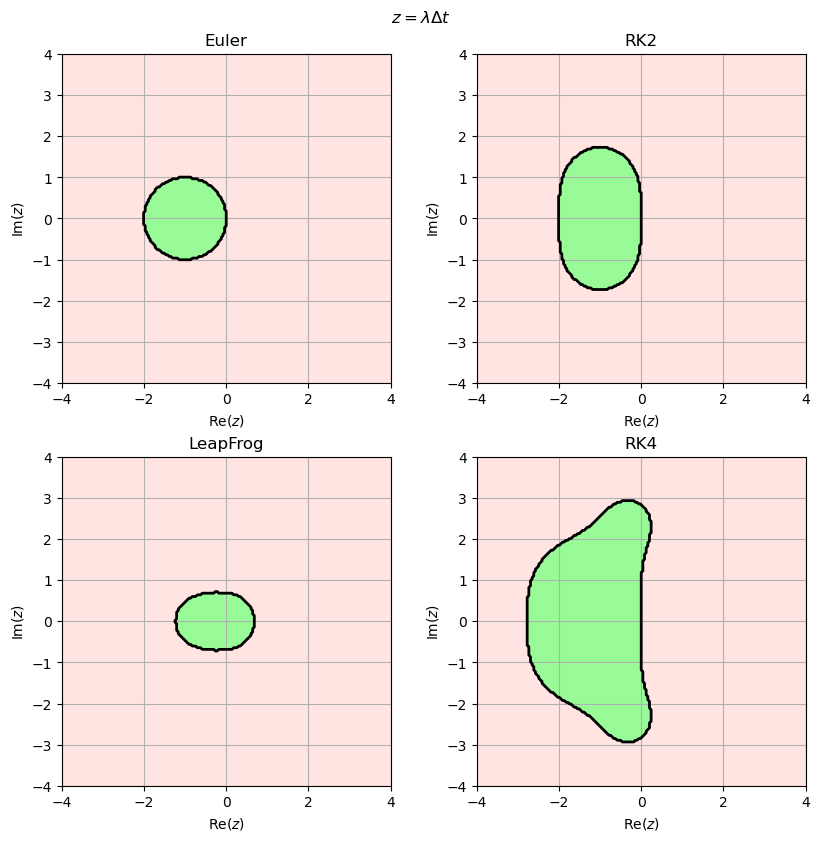

In [32]:
#Euler
z = np.exp(1.j*np.pi*np.linspace(0.0, 200.0, 1000)/100.0)



Re = np.linspace(-2.0, 2.0, 2000)
Im = np.linspace(-2.0, 2.0, 2000)

RR, II = np.meshgrid(Re, Im)
z=RR+1.0j*II


stab_Euler = lambda zz : np.abs(1.0+zz) <= 1.0
z_Euler = z[stab_Euler(z)]

pol_RK2 = lambda zz : np.abs(1.0+zz+(zz**2)/2.0)-1.0
stab_RK2 = lambda zz : pol_RK2(zz) <=0.0

pol_RK4 = lambda zz : np.abs(1.0 + zz + 0.5*zz**2 + (zz**3)/6.0 + (zz**4)/24.0)
stab_RK4 = lambda zz : pol_RK4(zz) <=1.0


def stab_LF(zz):
    zeta1 = zz+np.sqrt(1.0+zz**2)
    zeta2 = zz-np.sqrt(1.0+zz**2)
    pol_stab = zeta1+(1.0+zz)*zeta2
    return np.abs(pol_stab) <= 1.0
    
def stability_diagram(stab_func, ax=None, Re_inf=-4.0, Re_sup=4.0, Im_inf = -4.0, Im_sup=4.0, N=200, title = None):
    Re = np.linspace(Re_inf, Re_sup, N)
    Im = np.linspace(Im_inf, Im_sup, N)
    RR, II = np.meshgrid(Re, Im)
    z=RR+1.0j*II
    z_stab = stab_func(z)
    print(z[z_stab])
    if ax is None:
        ax = plt.axes()
    ax.set_facecolor('mistyrose')
    ax.contourf(RR, II, z_stab, levels = [0.5, 1.5], colors = 'palegreen')
    ax.contour(RR, II, z_stab,
               levels=[0.5],
               colors="black",
               linewidths=2)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$\operatorname{Re}(z)$")
    ax.set_ylabel(r"$\operatorname{Im}(z)$")
    ax.grid(True)
    if title is not None:
        ax.set_title(title)
    return ax



fig = plt.figure( figsize  = (8.3, 8.3), constrained_layout = True)
axs = fig.subplots(2, 2, squeeze = False, sharex = False, sharey = False)
fig.suptitle(r"$z = \lambda \Delta t$")

ax_Euler = stability_diagram(stab_Euler, ax = axs[0, 0], title = 'Euler')
ax_RK2 = stability_diagram(stab_RK2, ax=axs[0, 1], title = 'RK2')
ax_RK4 = stability_diagram(stab_RK4, ax=axs[1, 1], title = 'RK4')
ax_LF = stability_diagram(stab_LF, axs[1, 0], title = 'LeapFrog')
plt.savefig(r"C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\Rapport_stage_M2_POC\\Figures\\Stab_diag_TS.png")

liste_k [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
liste_z
[-0.46231156-2.91457286j -0.42211055-2.91457286j -0.38190955-2.91457286j
 

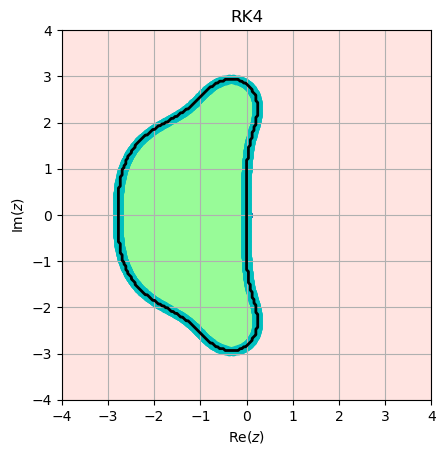

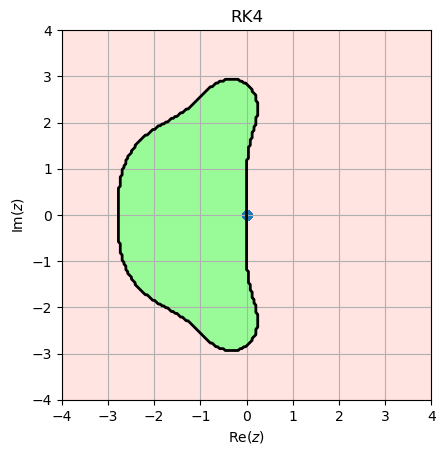

In [53]:
args_eigs_D1 = np.angle(eigs_D_N1)
dist_eigs_D1 = np.abs(eigs_D_N1)
z0 = complex(-0.0+0.0j)

liste_k = np.zeros_like(eigs_D_N1)
liste_z = np.zeros_like(eigs_D_N1)

def equation_rayon(func_r, r_sup=5.0):
    res = scipy.optimize.root_scalar(func_r, x0=1.0, bracket = (-1.0e-16, 5.0))
    r = res.root
    #r, res = scipy.optimize.brentq(func_r, -1.0e-16, 5.0, full_output = True)
    #print(res)
    return r
    
def eq_RK4(theta):
    return lambda rr:pol_RK4(rr*np.exp(1.j*theta))-1.0


Re = np.linspace(-4.0, 4.0, 1000)
Im = np.linspace(-4.0, 4.0, 1000)

RR, II = np.meshgrid(Re, Im)
Z=RR+1.0j*II
Z_mask = np.where(stab_RK4(Z), True, False)
z_contour = []
for i in range(0, Z_mask.shape[0]):
    slice_y_i = Z_mask[i, :]
    for j in range(0, Z_mask.shape[1]-1):
        #if (slice_y_i[j] & ~slice_y_i[j+1]) | (~slice_y_i[j] & slice_y_i[j+1]):
        if np.logical_xor(slice_y_i[j], slice_y_i[j+1]):
            z_contour.append(Z[i, j])
z_contour = np.array(z_contour)
z_contour_angle = np.angle(z_contour)
z_contour_abs = np.abs(z_contour)

z_con

for i in range(0, dist_eigs_D1.size):
    eig_i = eigs_D_N1[i]
    angle_i = args_eigs_D1
    #On détermine les deux angles les plus proches
    index_angle_right = np.searchsorted(z_contour_angle, angle_i, side = 'right')
    index_angle_left = np.searchsorted(z_contour_angle, angle_i, side = 'left')
    
print(f"liste_k {liste_k}")
print(f"liste_z")
fig = plt.figure()
ax_RK4 = stability_diagram(stab_RK4, title = 'RK4')
ax_RK4.scatter(liste_z.real, liste_z.imag)
ax_RK4.scatter(z_contour.real, z_contour.imag, color = 'c')
k_min  = np.abs(liste_k).astype('float64').min()
eigs_corr = k_min*eigs_D_N1

print(f"k_min = {k_min}")
print(f"eigs_corr = {eigs_corr}")


fig = plt.figure()
ax_RK4 = stability_diagram(stab_RK4, title = 'RK4')
ax_RK4.scatter(eigs_corr.real, eigs_corr.imag)

In [51]:
z_contour.size

In [57]:
eigs_corr.imag

array([ 33.78536907, -33.78536907,  33.78536907, -33.78536907,
        16.42766766, -16.42766766,  16.42766766, -16.42766766,
        10.85945682, -10.85945682,  10.85945682, -10.85945682,
         8.13475203,  -8.13475203,   8.13475203,  -8.13475203,
         6.52763711,  -6.52763711,   6.52763711,  -6.52763711,
         5.47377704,  -5.47377704,   5.47377704,  -5.47377704,
         4.73449924,  -4.73449924,   4.73449924,  -4.73449924,
         4.19182864,  -4.19182864,   4.19182864,  -4.19182864,
         3.78111594,  -3.78111594,   3.78111594,  -3.78111594,
         3.46448229,  -3.46448229,   3.46448229,  -3.46448229,
         3.21900652,  -3.21900652,   3.21900652,  -3.21900652,
         3.02980692,  -3.02980692,   3.02980692,  -3.02980692,
         2.89313358,  -2.89313358,   2.86395503,  -2.86395503,
         2.77025099,  -2.77025099,   2.69826759,  -2.69826759,
         2.62206926,  -2.62206926,   2.54657781,  -2.54657781,
         2.47088649,  -2.47088649,   2.39515089,  -2.39

In [ ]:
eig

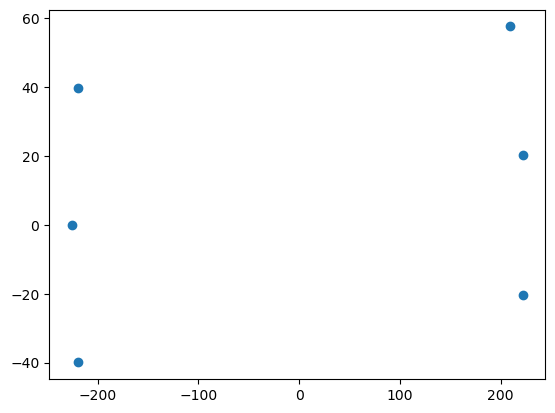

In [90]:
ChebFFT1_LO = scipy.sparse.linalg.LinearOperator((128,128), lambda xx: Chebyshev.ChebDiff_FFT(xx, M=1))
ChebFFT1_eigval = scipy.sparse.linalg.eigs(ChebFFT1_LO, return_eigenvectors = False, tol =1.0e-12)
plt.scatter(ChebFFT1_eigval.real, ChebFFT1_eigval.imag)

In [52]:
5.0*np.exp(1.0j*np.pi/6.0)

(4.330127018922194+2.4999999999999996j)

In [55]:
equation_rayon(2.0, np.pi/6.0)

3.6251816013442397

In [ ]:
liste_angles = np.linspace(-np.pi, np.pi, endoint = False)

In [73]:
print(np.sort(np.arctan2(z_contour.imag, z_contour.real)))

[-3.14015793 -3.13728852 -3.13441918 ...  3.13441918  3.13728852
  3.14015793]


In [66]:
print(np.sort(args_eigs_D1))

[-1.82732703 -1.72250432 -1.68063092 -1.65722559 -1.64187389 -1.63076405
 -1.62213337 -1.61502025 -1.60880214 -1.60294446 -1.5966791  -1.58818012
 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633
 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633
 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633
 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633
 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633
 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633 -1.57079633
 -1.57079633 -1.57079633 -1.57079633 -1.55341253 -1.54491355 -1.5386482
 -1.53279052 -1.5265724  -1.51945928 -1.5108286  -1.49971876 -1.48436707
 -1.46096173 -1.41908834 -1.31426562  0.          0.          1.31426562
  1.41908834  1.46096173  1.48436707  1.49971876  1.5108286   1.51945928
  1.5265724   1.53279052  1.5386482   1.54491355  1.55341253  1.57079633
  1.57079633  1.57079633  1.57079633  1.57079633  1.

In [55]:
np.pi/2.0

In [74]:
a = np.array([-0.1, 0.1, 2.0, 3.0])
right_index = np.searchsorted(a, 0.0, side = 'right')
#right_index = np.clip(right_index, 1, a.size-1)
left_index = np.searchsorted(a, 0.0, side = 'left')

a_right= a[right_index]
a_left= a[left_index]


print(f"right_index = {right_index}")
print(f"left_index = {left_index}")

print(f"interp en 0 {np.interp(0.0, [a_left, a_right], [-1.0, 1.0])}")

right_index = 1
left_index = 1
interp en 0 -1.0


In [77]:
aa=np.argpartition(a, 2)
aa

array([0, 1, 2, 3], dtype=int64)

In [71]:
# 1. Génération de données d'exemple (angles en radians entre -pi et pi)
a = np.random.uniform(-np.pi, np.pi, 1000)
b = 3.12  # Angle cible scalaire proche de la frontière pi / -pi

# 2. Trouver les deux angles de 'a' les plus proches (approche géométrique)
# On calcule l'écart angulaire minimal sur le cercle
ecarts = np.arctan2(np.sin(a - b), np.cos(a - b))
indices_2_proches = np.argpartition(np.abs(ecarts), 2)[:2]

# On extrait les deux angles les plus proches
angle_1 = a[indices_2_proches[0]]
angle_2 = a[indices_2_proches[1]]

# 3. Calcul du poids (fraction) de b entre angle_1 et angle_2
# On calcule la distance angulaire totale signée entre les deux voisins
diff_totale = np.arctan2(np.sin(angle_2 - angle_1), np.cos(angle_2 - angle_1))

# On calcule la distance angulaire signée entre le premier voisin et notre cible b
diff_cible = np.arctan2(np.sin(b - angle_1), np.cos(b - angle_1))

# Le poids détermine où se situe 'b' entre angle_1 (poids=0) et angle_2 (poids=1)
poids = diff_cible / diff_totale

# 4. Interpolation linéaire sur le chemin le plus court
# On avance depuis angle_1 en direction de angle_2 selon le poids calculé
angle_interpole = angle_1 + poids * diff_totale

# 5. Normalisation du résultat entre -pi et pi
angle_interpole = np.arctan2(np.sin(angle_interpole), np.cos(angle_interpole))

print(f"Cible b : {b:.4f} rad")
# Affiche l'angle final calculé (qui sera mathématiquement égal à b)
print(f"Angle interpolé : {angle_interpole:.4f} rad") 

Cible b : 3.1200 rad
Angle interpolé : 3.1200 rad
